In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)

DATA_PATH = Path("../data/raw/creditcard.csv")
FIGURE_PATH = Path("../reports/figures")
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
missing_percentage = df.isnull().mean().sort_values(ascending=False) * 100
missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

The dataset does not contain missing values, so no missing-value imputation is required at this stage.

In [8]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 4), "%")

Duplicate rows: 1081
Duplicate percentage: 0.3796 %


In [9]:
class_counts = df["Class"].value_counts()
class_percentages = df["Class"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_summary

,Count,Percentage
Class,,
0,284315,99.827251
1,492,0.172749


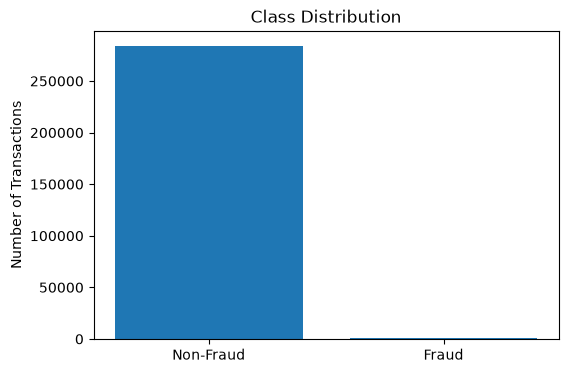

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(["Non-Fraud", "Fraud"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.savefig(FIGURE_PATH / "class_distribution.png", bbox_inches="tight")
plt.show()

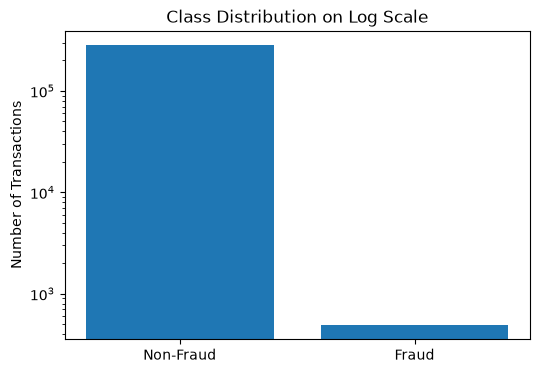

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(["Non-Fraud", "Fraud"], class_counts.values)
plt.yscale("log")
plt.title("Class Distribution on Log Scale")
plt.ylabel("Number of Transactions")
plt.savefig(FIGURE_PATH / "class_distribution_log_scale.png", bbox_inches="tight")
plt.show()

In [12]:
num_non_fraud = class_counts[0]
num_fraud = class_counts[1]

imbalance_ratio = num_non_fraud / num_fraud
fraud_percentage = class_percentages[1]

print("Non-fraud transactions:", num_non_fraud)
print("Fraud transactions:", num_fraud)
print("Fraud percentage:", round(fraud_percentage, 4), "%")
print("Imbalance ratio:", round(imbalance_ratio, 2), ": 1")

Non-fraud transactions: 284315
Fraud transactions: 492
Fraud percentage: 0.1727 %
Imbalance ratio: 577.88 : 1


This dataset is highly imbalanced, we will have to take care of this in future steps

In [13]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [14]:
amount_summary = df.groupby("Class")["Amount"].describe()
amount_summary

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


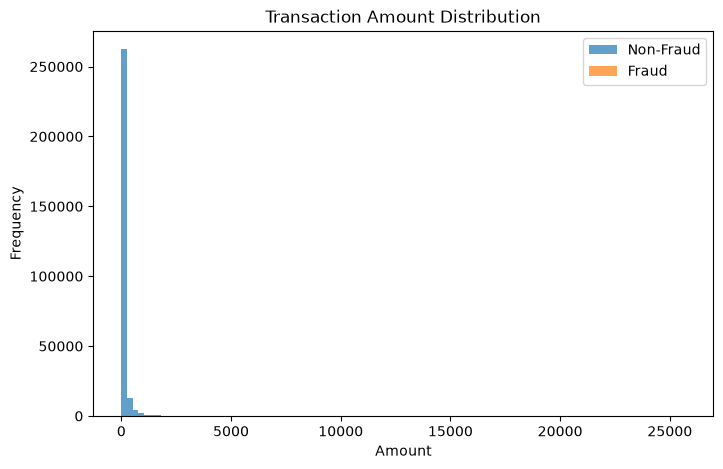

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["Class"] == 0]["Amount"], bins=100, alpha=0.7, label="Non-Fraud")
plt.hist(df[df["Class"] == 1]["Amount"], bins=100, alpha=0.7, label="Fraud")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(FIGURE_PATH / "amount_distribution.png", bbox_inches="tight")
plt.show()

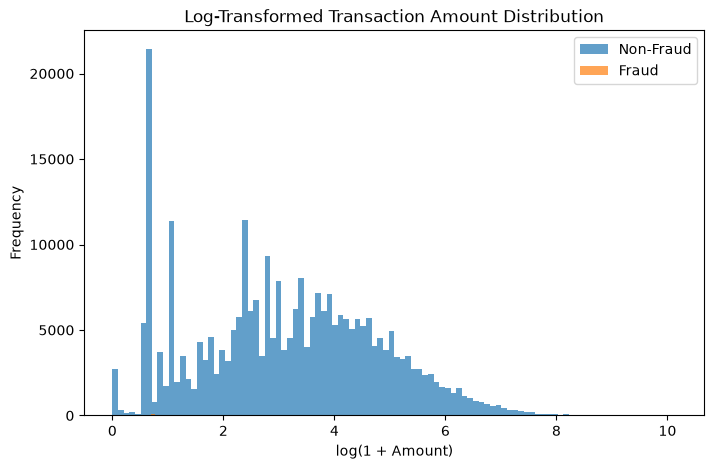

In [16]:
df["LogAmount"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 5))
plt.hist(df[df["Class"] == 0]["LogAmount"], bins=100, alpha=0.7, label="Non-Fraud")
plt.hist(df[df["Class"] == 1]["LogAmount"], bins=100, alpha=0.7, label="Fraud")
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(FIGURE_PATH / "log_amount_distribution.png", bbox_inches="tight")
plt.show()

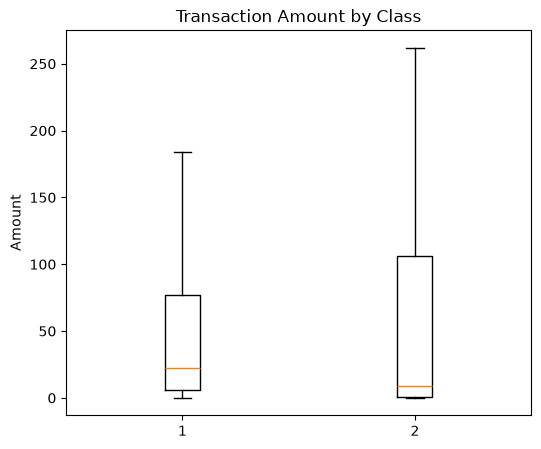

In [18]:
plt.figure(figsize=(6, 5))
plt.boxplot(
    [df[df["Class"] == 0]["Amount"], df[df["Class"] == 1]["Amount"]],
    label=["Non-Fraud", "Fraud"],
    showfliers=False
)
plt.title("Transaction Amount by Class")
plt.ylabel("Amount")
plt.savefig(FIGURE_PATH / "amount_boxplot_by_class.png", bbox_inches="tight")
plt.show()

In [19]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Day"] = df["Time"] // (3600 * 24)

In [20]:
hourly_counts = df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)
hourly_counts

Class,0,1
Hour,,
0.0,7689,6
1.0,4210,10
2.0,3271,57
3.0,3475,17
4.0,2186,23
5.0,2979,11
6.0,4092,9
7.0,7220,23
8.0,10267,9


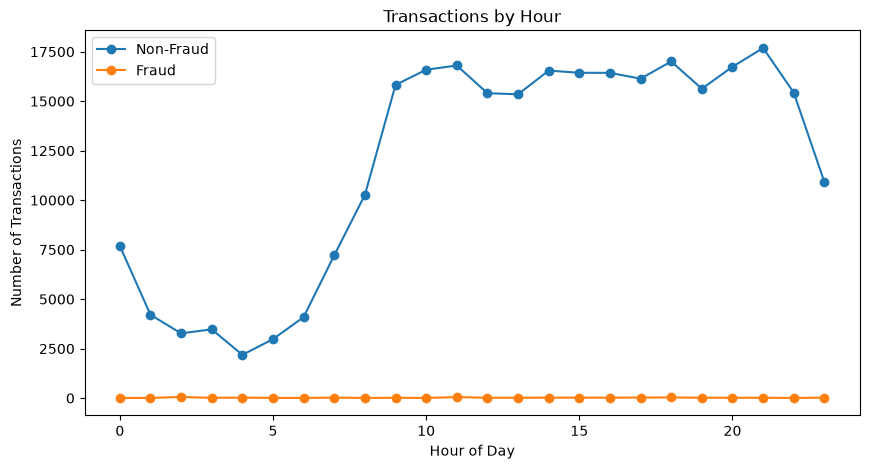

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_counts.index, hourly_counts[0], marker="o", label="Non-Fraud")
plt.plot(hourly_counts.index, hourly_counts[1], marker="o", label="Fraud")
plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.legend()
plt.savefig(FIGURE_PATH / "transactions_by_hour.png", bbox_inches="tight")
plt.show()

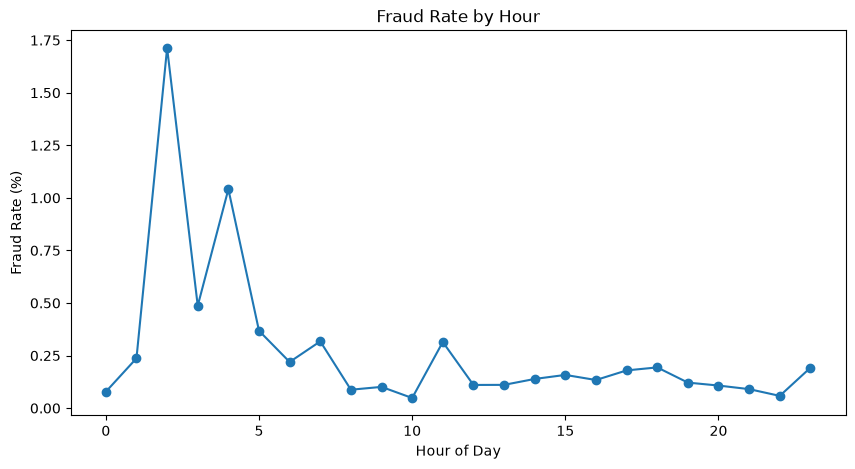

In [22]:
hourly_fraud_rate = df.groupby("Hour")["Class"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(hourly_fraud_rate.index, hourly_fraud_rate.values, marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.savefig(FIGURE_PATH / "fraud_rate_by_hour.png", bbox_inches="tight")
plt.show()

In [23]:
pca_features = [col for col in df.columns if col.startswith("V")]
len(pca_features)

28

In [24]:
pca_class_means = df.groupby("Class")[pca_features].mean().T
pca_class_means["absolute_difference"] = abs(pca_class_means[1] - pca_class_means[0])
pca_class_means.sort_values("absolute_difference", ascending=False).head(10)

Class,0,1,absolute_difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


In [25]:
top_features = pca_class_means.sort_values(
    "absolute_difference", ascending=False
).head(8).index.tolist()

top_features

['V3', 'V14', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4']

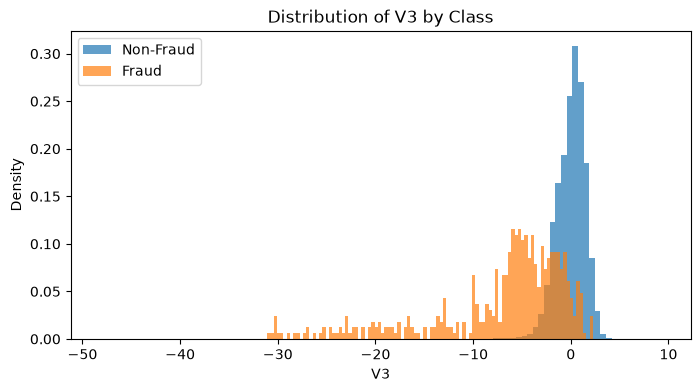

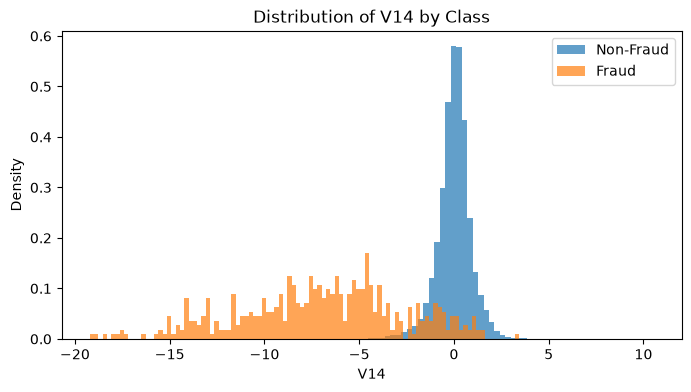

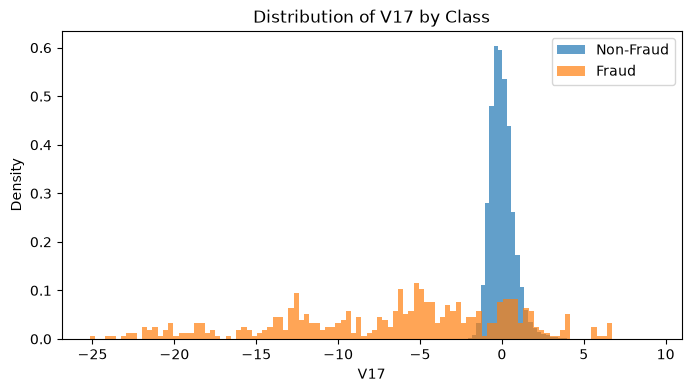

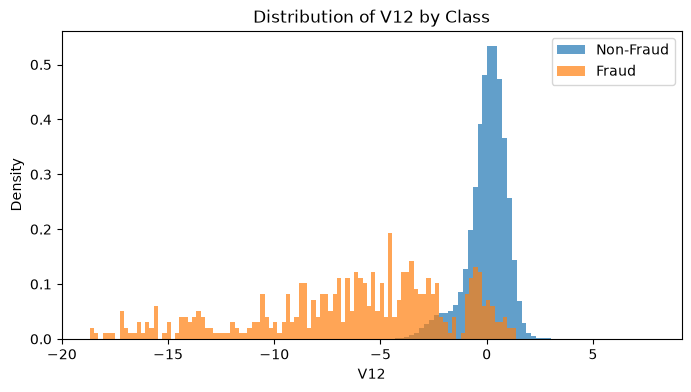

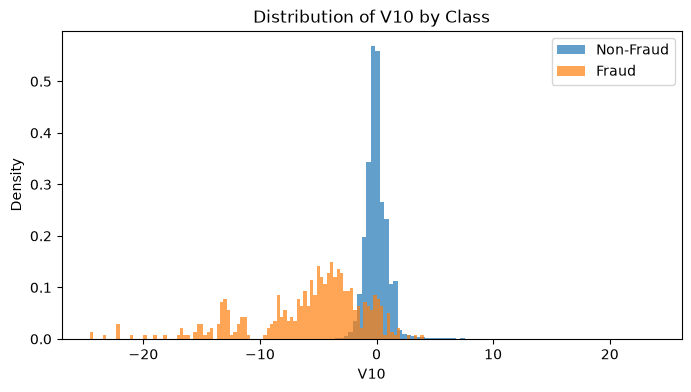

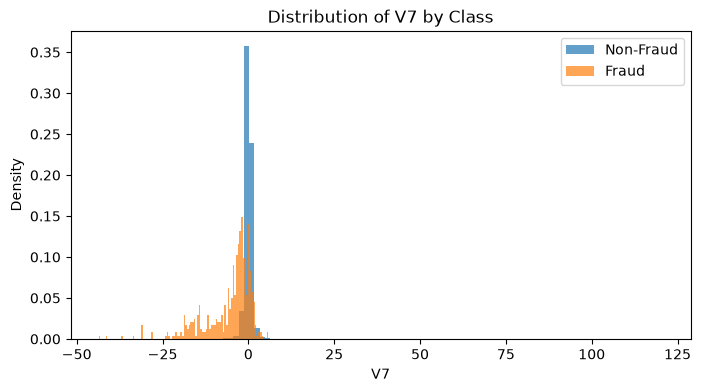

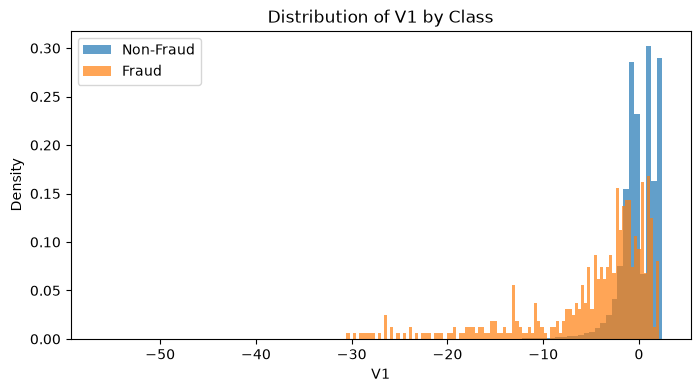

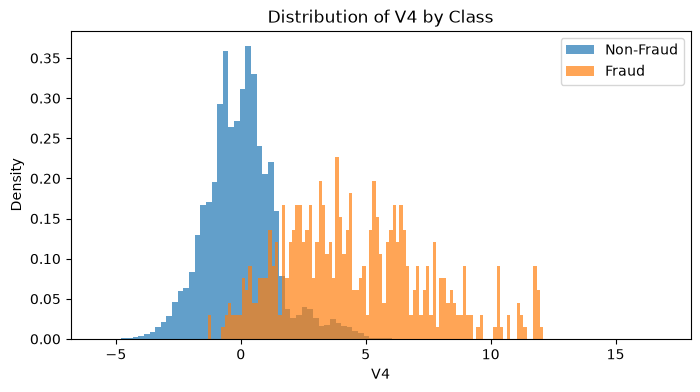

In [26]:
for feature in top_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df[df["Class"] == 0][feature], bins=100, alpha=0.7, label="Non-Fraud", density=True)
    plt.hist(df[df["Class"] == 1][feature], bins=100, alpha=0.7, label="Fraud", density=True)
    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.savefig(FIGURE_PATH / f"{feature}_distribution_by_class.png", bbox_inches="tight")
    plt.show()

In [27]:
correlations = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
correlations

Class        1.000000
V11          0.154876
V4           0.133447
V2           0.091289
V21          0.040413
V19          0.034783
V20          0.020090
V8           0.019875
V27          0.017580
V28          0.009536
Amount       0.005632
V26          0.004455
V25          0.003308
V22          0.000805
V23         -0.002685
V15         -0.004223
V13         -0.004570
Day         -0.005223
V24         -0.007221
LogAmount   -0.008326
Time        -0.012323
Hour        -0.017109
V6          -0.043643
V5          -0.094974
V9          -0.097733
V1          -0.101347
V18         -0.111485
V7          -0.187257
V3          -0.192961
V16         -0.196539
V10         -0.216883
V12         -0.260593
V14         -0.302544
V17         -0.326481
Name: Class, dtype: float64

In [28]:
print("Top positive correlations with fraud:")
print(correlations.head(10))

print("\nTop negative correlations with fraud:")
print(correlations.tail(10))

Top positive correlations with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top negative correlations with fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


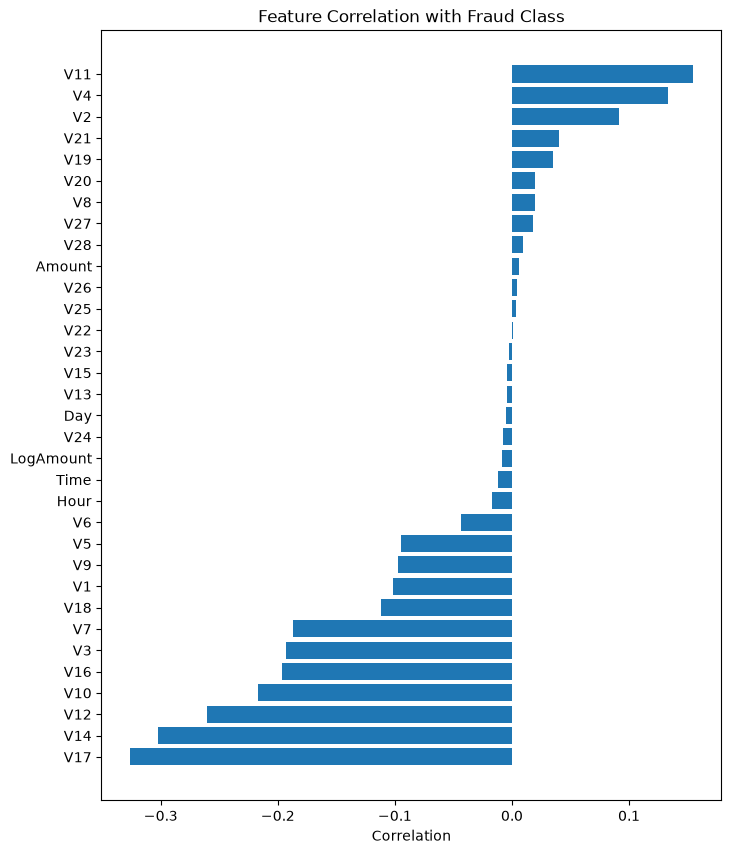

In [29]:
target_corr = correlations.drop("Class").sort_values()

plt.figure(figsize=(8, 10))
plt.barh(target_corr.index, target_corr.values)
plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation")
plt.savefig(FIGURE_PATH / "feature_correlation_with_class.png", bbox_inches="tight")
plt.show()

In [30]:
skewness = df.drop(columns=["Class"]).skew().sort_values(ascending=False)
skewness.head(10)

Amount    16.977724
V28       11.192091
V21        3.592991
V7         2.553907
V6         1.826581
V10        1.187141
V4         0.676292
V26        0.576693
V9         0.554680
V11        0.356506
dtype: float64

In [31]:
skewness.tail(10)

V14   -1.995176
V20   -2.037155
V3    -2.240155
V12   -2.278401
V5    -2.425901
V1    -3.280667
V17   -3.844914
V2    -4.624866
V23   -5.875140
V8    -8.521944
dtype: float64

In [32]:
summary_path = Path("../reports")

class_summary.to_csv(summary_path / "class_distribution_summary.csv")
amount_summary.to_csv(summary_path / "amount_summary_by_class.csv")
correlations.to_csv(summary_path / "feature_target_correlations.csv")

print("EDA summaries saved successfully.")

EDA summaries saved successfully.
